📊 Dataset Loaded Successfully!

   Unnamed: 0 trans_date_trans_time            cc_num  \
0           0   2019-01-01 00:00:18  2703186189652095   
1           1   2019-01-01 00:00:44      630423337322   
2           2   2019-01-01 00:00:51    38859492057661   
3           3   2019-01-01 00:01:16  3534093764340240   
4           4   2019-01-01 00:03:06   375534208663984   

                             merchant       category     amt      first  \
0          fraud_Rippin, Kub and Mann       misc_net    4.97   Jennifer   
1     fraud_Heller, Gutmann and Zieme    grocery_pos  107.23  Stephanie   
2                fraud_Lind-Buckridge  entertainment  220.11     Edward   
3  fraud_Kutch, Hermiston and Farrell  gas_transport   45.00     Jeremy   
4                 fraud_Keeling-Crist       misc_pos   41.96      Tyler   

      last gender                        street  ...      lat      long  \
0    Banks      F                561 Perry Cove  ...  36.0788  -81.1781   
1     Gill      F  43039

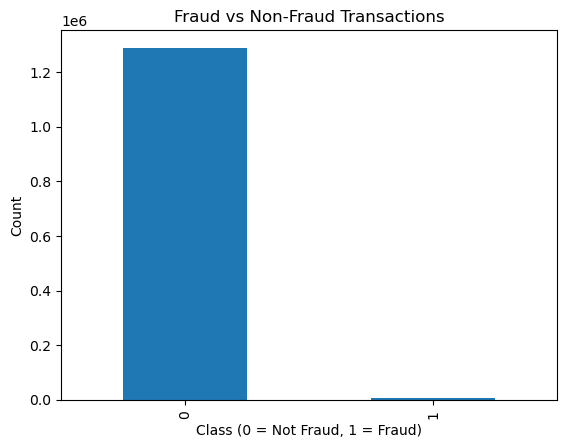


🚀 Model Training Completed!

✅ Model Performance:

Accuracy: 0.9963637765824127

📄 Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257815
           1       0.71      0.63      0.67      1520

    accuracy                           1.00    259335
   macro avg       0.86      0.82      0.83    259335
weighted avg       1.00      1.00      1.00    259335


📊 Confusion Matrix:
[[257428    387]
 [   556    964]]


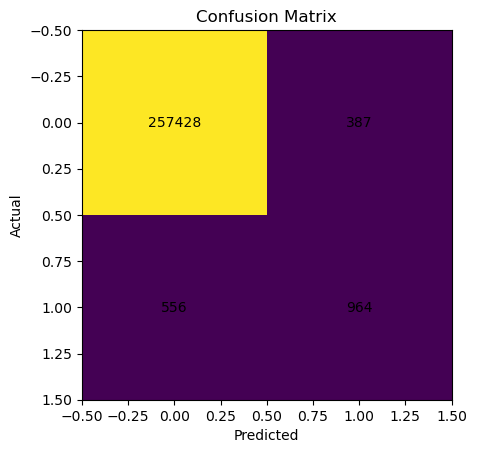


✅ Transaction is Legitimate.


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv("fraudTrain.csv")

print("📊 Dataset Loaded Successfully!\n")
print(df.head())

df = df[['amt', 'category', 'gender', 'is_fraud']]

le = LabelEncoder()
df['category'] = le.fit_transform(df['category'])
df['gender'] = le.fit_transform(df['gender'])

print("\n📊 Fraud vs Non-Fraud Count:")
print(df['is_fraud'].value_counts())

df['is_fraud'].value_counts().plot(kind='bar')
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Class (0 = Not Fraud, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier()
model.fit(X_train, y_train)

print("\n🚀 Model Training Completed!")

y_pred = model.predict(X_test)

print("\n✅ Model Performance:\n")
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\n📄 Classification Report:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

print("\n📊 Confusion Matrix:")
print(cm)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j], ha='center', va='center')

plt.show()

sample = [[150.0, 2, 1]]

prediction = model.predict(sample)[0]

if prediction == 1:
    print("\n⚠️ ALERT: Fraudulent Transaction Detected!")
else:
    print("\n✅ Transaction is Legitimate.")